# Stylized Facts of Returns: Heavy Tails
#### Scikit-Learn KDE on NVIDIA cuML

### Notebook Outline

**1 · Stylized Fact** — returns vs. the normal model (VaR / CAPM / Black-Scholes)  
**2 · Data** — intraday returns, 100 large-caps & ETFs 
**3 · Empirical v Normal** — emperical distribution vs. normal model
**4 · KDE TL;DR** — visual explanation of KDE. 
**5 · CPU Benchmark** — CPU baseline  
**6 · NVIDIA cuML** — GPU-accelerated scikit-learn API  
**7 · CPU vs GPU Benchmark** — across sample sizes  
**8 · Next steps**  

**TL;DR — Run `%load_ext cuml.accel` before sklearn imports and `sklearn.neighbors.KernelDensity` runs on your NVIDIA GPU.** 

Notebook rendered with **AMD Threadripper PRO 7965WX** CPU with 48 threads and **NVIDIA RTX PRO 6000 Blackwell (96GB)** GPU.  
 - CPU: **~4 minutes to run bootstrap**
 - GPU: **~seconds to run bootstrap**

## Install NVIDIA cuML and NVIDIA cuDF

```bash

uv pip install --extra-index-url=https://pypi.nvidia.com cuml-cu13 cudf-cu13
~ OR ~
# pip
pip install --extra-index-url=https://pypi.nvidia.com cuml-cu13 cudf-cu13
```

Requirements: an NVIDIA GPU with a CUDA 13 driver (r580+).
If using **CUDA 12**, change the above dependencies to **cuml-cu12 cudf-cu12**.
Pre-installed when a GPU is attached:
 - Google Colab
 - Kaggle
 - Google Colab Enterprise 

In [1]:
!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv,noheader
# CPU model (so the render self-documents the baseline hardware, not just the GPU):
!grep -m1 'model name' /proc/cpuinfo | cut -d: -f2 | sed 's/^ //'

NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 580.105.08, 97887 MiB


AMD Ryzen Threadripper PRO 7965WX 24-Cores


# 1. A Stylized Fact of Returns → Returns Are Not Normal

 - **VaR**
 - **CAPM**
 - **Black-Scholes**

These model returns as a normal distribution. Real returns are **leptokurtic** (tall narrow peak) with **heavy tails**.

A **kernel density estimate (KDE)** 
 - recovers the actual density from the data
 - no distribution assumed
 - **bootstrap band** (100–1,000 KDE refits) indicates stability  
   
 The refit loop's cost scales with *(samples × query-grid)* per fit.

# 2. Data: 5-Min Bar Returns for 100 Large Caps and ETFs

**Feb 2 – Jun 3, 2026**

In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
import time

# Pre-computed 5-minute returns [ticker, ret]
CANDIDATES = ["intraday_returns_5m.parquet", "../data/intraday_returns_5m.parquet"]
DATA_PATH = next((p for p in CANDIDATES if Path(p).exists()), CANDIDATES[0])

Path("images").mkdir(parents=True, exist_ok=True)  # figures save here

all_returns = pd.read_parquet(DATA_PATH)
display(all_returns.head())

print(f"{all_returns['ticker'].nunique()} tickers")
print(f"{len(all_returns):,} pooled 5-minute return observations")
print("window: Feb 2 – Jun 3, 2026  (~4 months of 5-minute bars)")
print(f"mean={all_returns['ret'].mean():.2e}  std={all_returns['ret'].std():.4f}  "
      f"min={all_returns['ret'].min():.3f}  max={all_returns['ret'].max():.3f}")
print("prep filter: |r| > 5% dropped as bad ticks (see data/consolidator_nbs/build_intraday_returns.py)")

,ticker,ret
0,AAPL,-0.000169
1,AAPL,0.000506
2,AAPL,-0.000599
3,AAPL,0.000899
4,AAPL,-0.000075


100 tickers
649,011 pooled 5-minute return observations
window: Feb 2 – Jun 3, 2026  (~4 months of 5-minute bars)
mean=5.60e-06  std=0.0018  min=-0.044  max=0.038
prep filter: |r| > 5% dropped as bad ticks (see data/consolidator_nbs/build_intraday_returns.py)


### The Bootstrap Function

Confidence bands come from **bootstrapping** --> resampling returns w/ replacement and refit the KDE multiple times, then read a band off the spread of those refits.  
Below is a single function to perform the bootstrapping `bootstrap_kde()` that returns timing and density curves to be plotted.  
A single function helps with CPU and GPU comparison and showing the same Scikit-Learn code runs on GPU.

In [3]:
from sklearn.neighbors import KernelDensity

N_BOOT_HEADLINE = 100   
N_BOOT = N_BOOT_HEADLINE
N_SAMPLES = 50_000
KDE_BANDWIDTH = 0.0002

# Fixed evaluation grid: +/- 2% in 5-minute return space.
GRID = np.linspace(-0.02, 0.02, 5000).reshape(-1, 1)

In [4]:
def bootstrap_kde(returns, n_samples=N_SAMPLES, n_boot=N_BOOT_HEADLINE, bandwidth=KDE_BANDWIDTH, seed=0):
    """Bootstrap KDE of a return sample. Returns timing + density band."""
    densities = np.empty((n_boot, len(GRID)))

    t0 = time.perf_counter()
    for i in range(n_boot):
        sample = returns.sample(n=n_samples, replace=True, random_state=seed + i).values.reshape(-1, 1)
        kde = KernelDensity(bandwidth=bandwidth, kernel="gaussian").fit(sample)
        densities[i] = np.exp(kde.score_samples(GRID))
    fit_seconds = time.perf_counter() - t0

    return {
        "fit_seconds": fit_seconds,
        "n_samples": n_samples,
        "n_boot": n_boot,
        "mean": densities.mean(axis=0),
        "lo": np.percentile(densities, 5, axis=0),
        "hi": np.percentile(densities, 95, axis=0),
    }

Run on CPU first 6-7 minutes on 48 Thread CPU

In [5]:
import sys
assert "cuml.accel" not in sys.modules, "cuml.accel loaded — restart kernel for a true CPU baseline"

cpu_run = bootstrap_kde(all_returns['ret'], 
                        n_samples=N_SAMPLES, 
                        n_boot=N_BOOT_HEADLINE, 
                        bandwidth=KDE_BANDWIDTH)

print(f"KDE CPU: {cpu_run['fit_seconds']:.2f}s ({cpu_run['n_boot']} fits x {cpu_run['n_samples']:,} samples)")

KDE CPU: 246.18s (100 fits x 50,000 samples)


# 3. Returns vs. the Normal Model

The empirical density (KDE + bootstrap band) vs normal, and the ratio between them.  
The heavy tails are absent from the normal distribution.  
Reference: [Cont (2001), *Empirical properties of asset returns*](https://doi.org/10.1080/713665670)

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis

plt.style.use("dark_background")
NV_GREEN, NV_BLUE, BAD_RED, AMBER = "#76b900", "#5eaeff", "#ff5e5e", "#ffb84d"

# Shared plot data: grid + the headline bootstrap result from Section 2.
_run = cpu_run
g = GRID.ravel()
g_pct = g * 100
mu = all_returns['ret'].mean()
sigma = all_returns['ret'].std()
gaussian = norm.pdf(g, loc=mu, scale=sigma)
mean, lo, hi = _run["mean"], _run["lo"], _run["hi"]
ratio = mean / np.clip(gaussian, 1e-300, None)

# Tail exceedance vs. the matched normal — count-based, no KDE/grid artifacts.
THRESH = 0.01
p_emp = (all_returns['ret'].abs() > THRESH).mean()
p_norm = norm.sf(THRESH, loc=mu, scale=sigma) + norm.cdf(-THRESH, loc=mu, scale=sigma)
tail_mult = p_emp / p_norm
print(f"|r| > 1% moves happen {tail_mult:,.0f}x more often than the matched normal predicts.")

|r| > 1% moves happen 92,349x more often than the matched normal predicts.


The bottom panel is **empirical / normal**  
How often each return value actually happens vs what the bell curve predicts.   

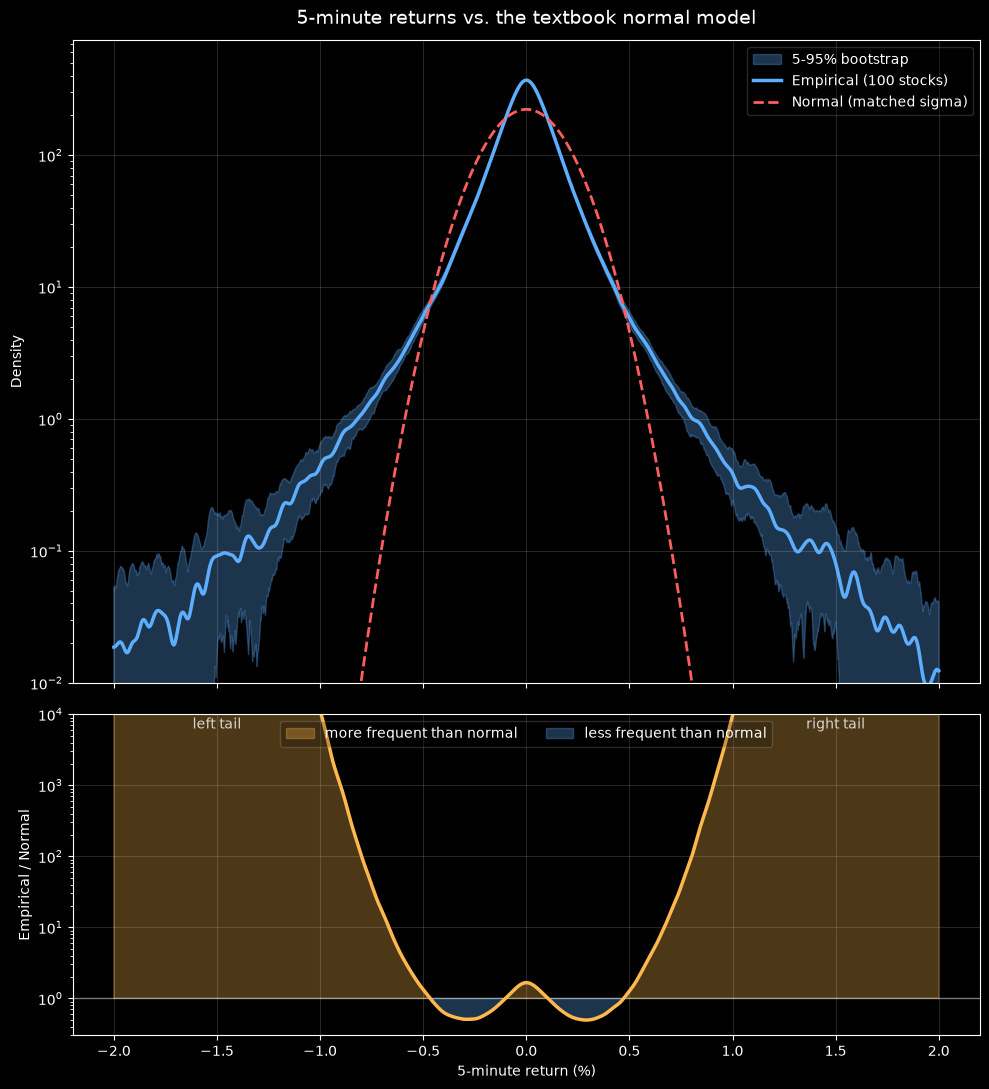

Excess kurtosis: 14.5   (normal = 0)
Largest move:    24.3 sigma   (pool pre-filtered to |r| <= 5%)
|r| > 1% moves happen 92,349x more often than the matched normal predicts.


In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 11), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

# Top: density on a log scale so the tails are visible.
ax1.fill_between(g_pct, lo, hi, color=NV_BLUE, alpha=0.30, label="5-95% bootstrap")
ax1.plot(g_pct, mean, color=NV_BLUE, lw=2.5, label="Empirical (100 stocks)")
ax1.plot(g_pct, gaussian, color=BAD_RED, lw=2, ls="--", label="Normal (matched sigma)")
ax1.set_yscale("log")
ax1.set_ylim(0.01, mean.max() * 2)
ax1.set_ylabel("Density")
ax1.legend(loc="upper right", framealpha=0.2)
ax1.set_title("5-minute returns vs. the textbook normal model", fontsize=14, pad=12)
ax1.grid(alpha=0.15)

# Bottom: empirical / normal ratio, with left/right tail callouts.
ax2.axhline(1, color="white", lw=1, alpha=0.4)
ax2.plot(g_pct, ratio, color=AMBER, lw=2.5)
ax2.fill_between(g_pct, 1, ratio, where=(ratio > 1), color=AMBER, alpha=0.3, label="more frequent than normal")
ax2.fill_between(g_pct, 1, ratio, where=(ratio < 1), color=NV_BLUE, alpha=0.3, label="less frequent than normal")
ax2.annotate("left tail", xy=(-1.5, min(ratio[g_pct < -1.5].max(), 9e3)), color="white", fontsize=10, ha="center", va="top", alpha=0.8)
ax2.annotate("right tail", xy=(1.5, min(ratio[g_pct > 1.5].max(), 9e3)), color="white", fontsize=10, ha="center", va="top", alpha=0.8)

ax2.set_yscale("log")
ax2.set_ylim(0.3, 1e4)
ax2.set_ylabel("Empirical / Normal")
ax2.set_xlabel("5-minute return (%)")
ax2.legend(loc="upper center", framealpha=0.2, ncol=2)
ax2.grid(alpha=0.15)

plt.tight_layout()
plt.savefig("images/intraday_density_ratio.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

# Headline stylized-fact numbers.
exc_kurt = kurtosis(all_returns["ret"], fisher=True)
max_sigma = np.abs(all_returns["ret"]).max() / sigma
print(f"Excess kurtosis: {exc_kurt:.1f}   (normal = 0)")
print(f"Largest move:    {max_sigma:.1f} sigma   (pool pre-filtered to |r| <= 5%)")
print(f"|r| > 1% moves happen {tail_mult:,.0f}x more often than the matched normal predicts.")

# 4. KDE TL;DR

KDE places a small **bump** (kernel) on every observation and adds them up.  
Places with dense return counts stack into peaks.  
The rare returns keep their own bump out in the tails.  
The toy example below uses a handful of points for visualization.

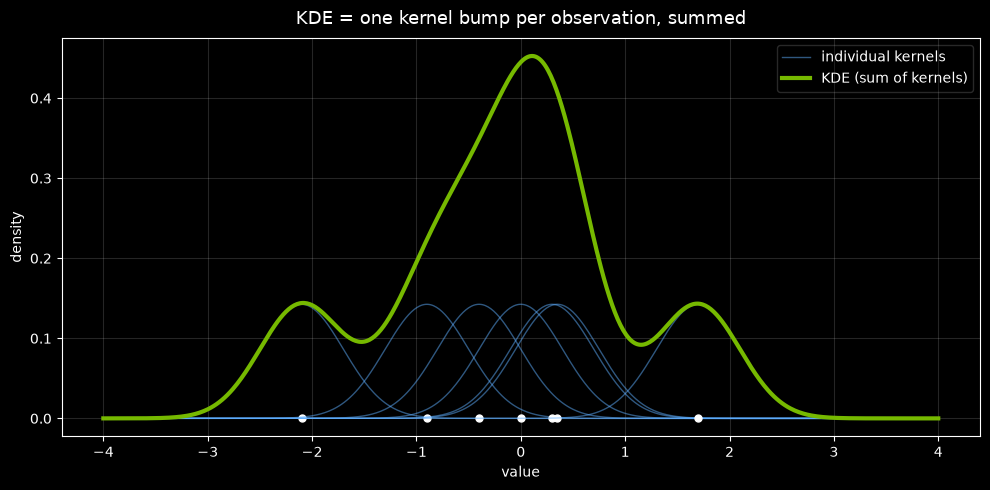

In [8]:
# Toy illustration: individual Gaussian kernels (thin) summing to the KDE (thick).
from sklearn.neighbors import KernelDensity as _KD

toy = np.array([-2.1, -0.9, -0.4, 0.0, 0.3, 0.35, 1.7])   # a few sample "returns"
bw = 0.4
xs = np.linspace(-4, 4, 600)

fig, ax = plt.subplots(figsize=(10, 5))

# Each observation's own kernel bump.
for j, x0 in enumerate(toy):
    bump = norm.pdf(xs, loc=x0, scale=bw) / len(toy)
    ax.plot(xs, bump, color=NV_BLUE, lw=1, alpha=0.5,
            label="individual kernels" if j == 0 else None)
    ax.plot([x0], [0], marker="o", color="white", ms=5)

# The KDE = sum of the bumps (via sklearn, so it matches the real method).
kde = _KD(bandwidth=bw, kernel="gaussian").fit(toy.reshape(-1, 1))
dens = np.exp(kde.score_samples(xs.reshape(-1, 1)))
ax.plot(xs, dens, color=NV_GREEN, lw=3, label="KDE (sum of kernels)")

ax.set_title("KDE = one kernel bump per observation, summed", fontsize=13, pad=10)
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.legend(loc="upper right", framealpha=0.2)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("images/kde_kernels_explainer.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

### KDE is built into scikit-learn

Scikit-Learn's KDE: [`sklearn.neighbors.KernelDensity`](https://scikit-learn.org/stable/modules/density.html#kernel-density-estimation).  

### Where else to use KDE

| Use case | Replaces | Caveat |
|---|---|---|
| Volume profile / value area | Histogram bins | Bandwidth choice matters |
| Monte Carlo risk sims | Normal return draws | iid resampling misses vol clustering |
| Trade expectancy | Win rate + avg win/loss | Needs ~200+ obs per condition |
| "How unusual is today?" | Per-feature z-scores | Keep it to ≤3 dimensions |
| Volatility bands | ±kσ | Fit a vol model first |


# 5. CPU Benchmark Grid

Using CPU-only, sweep the sample size for the full baseline curve.  
Note the wall time based on workload size.  

sklearn `KernelDensity` has no `n_jobs` so the baseline is the stock single-threaded sklearn workflow, not a saturated 24-core CPU.  
A full sweep takes ~1 hour on this CPU. The timings are saved to `kde_timings.json`.  

In [9]:
assert "cuml.accel" not in sys.modules, "cuml.accel loaded — restart kernel for a true CPU baseline"

SCALES = [10_000, 50_000, 100_000, 200_000]
N_BOOT_FULL = 1_000        # the workload the GPU grid runs in full
CPU_BOOT = 100             # CPU timed on fewer bootstraps, then scaled (time is linear in n_boot)


def time_sweep(pool, scales, n_boot, label, scale_to=None):
    """Time a KDE bootstrap sweep on the REAL return pool.
    If scale_to is set, linearly extrapolate fit time to that n_boot."""
    out = {}
    print(f"{label} grid ({n_boot} bootstraps"
          + (f", scaled to {scale_to})" if scale_to else ")") + ":")
    for n in scales:
        measured = bootstrap_kde(pool, n_samples=n, n_boot=n_boot)["fit_seconds"]
        out[n] = measured * (scale_to / n_boot) if scale_to else measured
        print(f"  n={n:>7,}: {out[n]:7.2f}s")
    return out


# CPU grid on the real pooled returns (scaled from CPU_BOOT -> N_BOOT_FULL).
cpu_grid = time_sweep(all_returns["ret"], SCALES, CPU_BOOT, "CPU", scale_to=N_BOOT_FULL)

# Anchor: one fully-measured CPU point at the full N_BOOT validates the linear scaling.
anchor_n = SCALES[0]
anchor_measured = bootstrap_kde(all_returns["ret"], n_samples=anchor_n, n_boot=N_BOOT_FULL)["fit_seconds"]
print(f"\nanchor (measured, full N_BOOT_FULL={N_BOOT_FULL}, n={anchor_n:,}): {anchor_measured:6.2f}s")
print(f"anchor (scaled  from CPU_BOOT={CPU_BOOT}):              {cpu_grid[anchor_n]:6.2f}s")
print(f"scaling error: {abs(anchor_measured - cpu_grid[anchor_n]) / anchor_measured:.1%}"
      "  (small -> linear-in-n_boot scaling is valid)")

CPU grid (100 bootstraps, scaled to 1000):


  n= 10,000:  256.30s


  n= 50,000: 2460.61s


  n=100,000: 6168.26s


  n=200,000: 15372.99s



anchor (measured, full N_BOOT_FULL=1000, n=10,000): 254.58s
anchor (scaled  from CPU_BOOT=100):              256.30s
scaling error: 0.7%  (small -> linear-in-n_boot scaling is valid)


# 6. GPU Acceleration w/ NVIDIA cuML
### <u>cuML</u> = <u>CU</u>DA-X for <u>M</u>achine <u>L</u>earning

https://developer.nvidia.com/topics/ai/data-science/cuda-x-data-science-libraries/cuml

### 6.1 Load `cuml.accel`

Normally you would load `cuml.accel` **before** your first sklearn import to run on the GPU.   
Here we load `cuml.accel` *after* the CPU to measure performance.

In [10]:
# GPU acceleration for pandas, similar to cuml.accel for Scikit-Learn
%load_ext cudf.pandas

In [ ]:
%load_ext cuml.accel

# Outside Notebooks/IPython: 

# import cuml.accel
# cuml.accel.install() 

# ~ or ~ 

# > python -m cuml.accel main.py


# Re-import so the cuml.accel-patched KernelDensity is used.
from sklearn.neighbors import KernelDensity

import pandas as pd
pd

<module 'pandas' (ModuleAccelerator(fast=cudf, slow=pandas))>

### 6.2 Same Scikit-Learn API on GPU

In [12]:
all_returns = pd.read_parquet(DATA_PATH)

# Same fit count as the CPU headline (N_BOOT_HEADLINE) so the speedup is apples-to-apples.
gpu_run = bootstrap_kde(all_returns["ret"], n_samples=N_SAMPLES, n_boot=N_BOOT_HEADLINE)
print(f"GPU bootstrap KDE: {gpu_run['fit_seconds']:.2f}s "
      f"({gpu_run['n_boot']} fits x {gpu_run['n_samples']:,} samples)")

GPU bootstrap KDE: 1.55s (100 fits x 50,000 samples)


### 6.3 GPU Speedup

In [13]:
speedup = cpu_run["fit_seconds"] / gpu_run["fit_seconds"]
print(f"CPU:     {cpu_run['fit_seconds']:7.2f}s")
print(f"GPU:     {gpu_run['fit_seconds']:7.2f}s")
print(f"Speedup: {speedup:7.1f}x")

CPU:      246.18s
GPU:        1.55s
Speedup:   158.5x


### 6.4 Validate CPU and GPU Result Agreement

GPU and CPU do not produce bit-identical numbers, but the **density curves** should overlay.  
We check the max absolute difference relative to the peak density.  
Each side draws its own bootstrap resamples, so the residual difference includes bootstrap noise, not just GPU numerics.  

In [14]:
rel_diff = np.abs(cpu_run["mean"] - gpu_run["mean"]).max() / cpu_run["mean"].max()
# Scientific notation: the difference is tiny but NONZERO — :.3% would round to a misleading "0.000%".
print(f"max relative difference between CPU and GPU density: {rel_diff:.2e}")
assert rel_diff < 0.05, "CPU and GPU densities diverge more than expected"
print("OK — CPU and GPU densities agree.")

max relative difference between CPU and GPU density: 1.61e-03
OK — CPU and GPU densities agree.


# 7. CPU vs GPU Benchmarks Across Sample Sizes

The CPU grid was timed in Section 5, before the NVIDIA cuML accelerator `cuml.accel` was loaded.   
Now run the **same sweep on the same data** on the GPU.  
**The larger the data, the more the GPU outperforms**  

### 7.1 GPU Grid

`cuml.accel` is loaded in Section 6, so the identical `time_sweep` now runs on the GPU.

In [15]:
gpu_grid = time_sweep(all_returns['ret'], SCALES, N_BOOT_FULL, "GPU")   # full N_BOOT_FULL on real returns — fast on GPU

GPU grid (1000 bootstraps):


  n= 10,000:    4.60s


  n= 50,000:   14.17s


  n=100,000:   25.91s


  n=200,000:   49.13s


### 7.2 Wall-Clock and Speedup

The speedup grows with sample size (more data per fit = more work to parallelize), so on this hardware it ranges from tens× at 10K samples to a few-hundred× at 200K.   
CPU times are timed at 100 bootstraps and scaled linearly to 1,000 (scaling validated in Section 5); GPU times run the full 1,000.  
All timings are from a single machine.  
Results depend on your cuML, driver, GPU; and are not bit-identical run-to-run. 

In [16]:
import json

bench = pd.DataFrame({
    "n_samples": SCALES,
    "cpu_s": [cpu_grid[n] for n in SCALES],
    "gpu_s": [gpu_grid[n] for n in SCALES],
})
bench["speedup"] = bench["cpu_s"] / bench["gpu_s"]
print(bench.to_string(index=False))

# Persist for the reel chart (matches 02-lw-turnover's lw_timings_*.json convention).
Path("kde_timings.json").write_text(json.dumps({
    "scales": SCALES,
    "cpu_s": [cpu_grid[n] for n in SCALES],
    "gpu_s": [gpu_grid[n] for n in SCALES],
    "hardware": "Threadripper PRO 7965WX + RTX PRO 6000 Blackwell",
    "cpu_method": "timed at 100 bootstraps, scaled linearly to 1000; linearity validated at n=10k (Section 5 anchor)",
}, indent=2))
print("\nSaved kde_timings.json")

 n_samples        cpu_s     gpu_s    speedup
     10000   256.296743  4.599421  55.723695
     50000  2460.610925 14.174972 173.588417
    100000  6168.264035 25.908171 238.081803
    200000 15372.988694 49.133832 312.879905

Saved kde_timings.json


### 7.3 Benchmark Visual

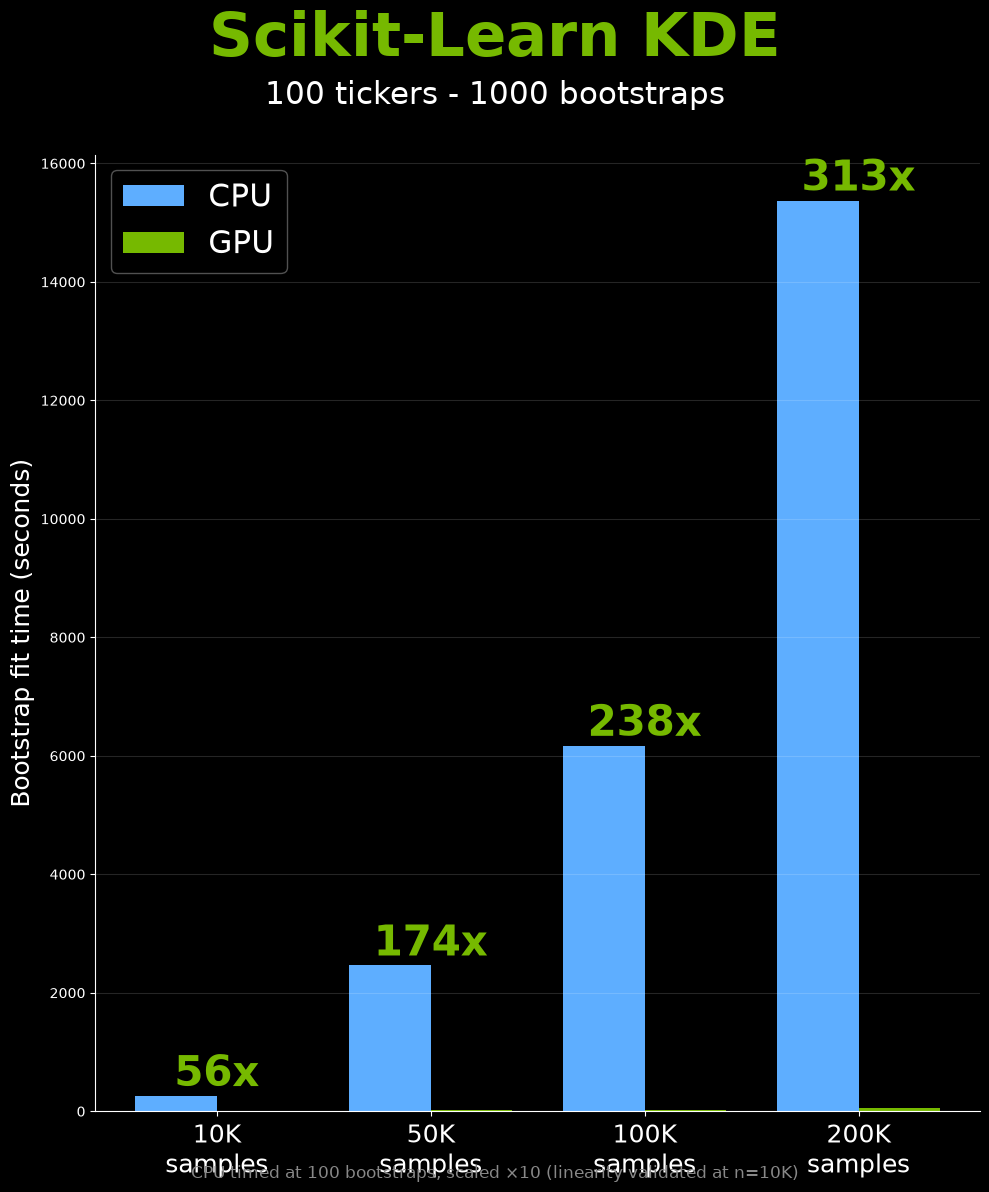

In [17]:
labels = ["10K", "50K", "100K", "200K"]
cpu_t = bench["cpu_s"].to_numpy()
gpu_t = bench["gpu_s"].to_numpy()
speedups = bench["speedup"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 12), facecolor="black")
ax.set_facecolor("black")
x = np.arange(len(SCALES))
w = 0.38
ax.bar(x - w/2, cpu_t, w, color=NV_BLUE, label="CPU")
ax.bar(x + w/2, gpu_t, w, color=NV_GREEN, label="GPU")
for i, (c, s) in enumerate(zip(cpu_t, speedups)):
    if np.isfinite(s):
        ax.text(i, c, f"{s:.0f}x", ha="center", va="bottom",
                fontsize=30, fontweight="bold", color=NV_GREEN)
ax.set_xticks(x)
ax.set_xticklabels([f"{l}\nsamples" for l in labels], fontsize=18)
ax.set_ylabel("Bootstrap fit time (seconds)", fontsize=18)
ax.legend(fontsize=22, loc="upper left", framealpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.15)
fig.text(0.5, 0.95, "Scikit-Learn KDE", ha="center", fontsize=44, fontweight="bold", color=NV_GREEN)
fig.text(0.5, 0.91, f"100 tickers - {N_BOOT_FULL} bootstraps", ha="center", fontsize=22, color="white")
plt.tight_layout(rect=[0, 0, 1, 0.88])
fig.text(0.5, 0.015, "CPU timed at 100 bootstraps, scaled ×10 (linearity validated at n=10K)",
         ha="center", fontsize=12, color="#888888")
plt.savefig("images/kde_benchmark.png", dpi=200, facecolor="black", bbox_inches="tight")
plt.show()

# 8. Next Steps

- **Try it on Colab / Kaggle.** Attach a GPU, run `%load_ext cuml.accel` at the top, and the notebook runs on GPU since cuML and cuDF are pre-installed.  
- **Try other estimators.** The same `%load_ext cuml.accel` line accelerates many other sklearn estimators (`PCA`, `KMeans`, `SpectralClustering`, `LedoitWolf`, ...).

*Educational benchmark, not a trading strategy.*